# Phase 3: Baseline Model Training and Checkpoint Evaluation

This notebook builds on the Phase 2 dataset-loading workflow and trains a first baseline CNN for multi-label chest X-ray classification. It also documents the checkpoint reuse workflow: the full training loop was run only once to create the best saved model weights, and later runs should load those saved weights directly to save time and GPU usage.

## 1. Import libraries and mount the image dataset

The notebook begins with the libraries needed for Kaggle access, image loading, tabular metadata, visualization, PyTorch modeling, optimization, learning-rate scheduling, and classification metrics. Mounting the NIH Chest X-ray image dataset is necessary because the Phase 1 CSV files store image paths that must point to real files during training and evaluation.


In [22]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
import torch
import torch.nn as nn
import numpy as np 
import torch.optim as optim
from torchvision import transforms
from torchvision.transforms import Compose
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report)
from timeit import default_timer as timer


# Instantly mounts the entire image folder system-wide in the background
# It returns the root directory containing all the 'images_001', 'images_002', etc. subfolders.
dataset_root_dir = Path(kagglehub.dataset_download("nih-chest-xrays/data"))

print(f"The images folder is mounted at: {dataset_root_dir}")



The images folder is mounted at: /kaggle/input/datasets/organizations/nih-chest-xrays/data


The printed path confirms that the Kaggle image dataset is available in the notebook environment. Later cells can use the `full_path` column from Phase 1 to open each X-ray file directly.


## 2. Define a custom PyTorch dataset

`ChestImageDataset` wraps each Phase 1 CSV file in a PyTorch `Dataset`. It reads image paths from `full_path`, opens each X-ray as a three-channel image, extracts the 14 disease-label columns, applies optional transforms, and returns one `(image, labels)` pair for any row index.


In [23]:
class ChestImageDataset(Dataset):
    def __init__(self, csv_url, transforms=None):
        self.data = pd.read_csv(csv_url)
        self.target_cols  = self.data.columns[10:-1].tolist()
        self.transforms = transforms
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        
        # Instant O(1) path lookup
        img_path = row['full_path']
        
        # Open and standardise image channels
        image = Image.open(img_path).convert("RGB")
        
        # Extract your one-hot columns
        labels = row[self.target_cols].values.astype('float32')
        labels = torch.tensor(labels)
        
        if self.transforms:
            image = self.transforms(image)
            
        return image, labels

This class definition does not print output. Once defined, it provides the reusable bridge between exported metadata rows and model-ready image-label pairs.


## 3. Define image preprocessing transforms

The transform pipeline resizes every X-ray to `224 x 224`, converts it to a tensor, and normalizes it with ImageNet mean and standard deviation values. This gives the baseline CNN a consistent input shape and scale across all splits.


In [24]:
data_transform = Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

This cell has no printed output. Successful execution creates `data_transform`, which standardizes all splits before they enter the model.


## 4. Build and check the training dataset

The training CSV is loaded into the custom dataset class with the transform pipeline attached. A single training example is indexed before batching so image loading, resizing, tensor conversion, and label extraction can be checked early.


In [25]:
train_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/train_data.csv",  
    transforms=data_transform
)
image,labels = train_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The output should show an image tensor shaped `[3, 224, 224]` and a label tensor shaped `[14]`. That confirms each image is converted to three channels, resized correctly, and paired with one target value per disease label.


A representative training image is displayed with its positive label names as the title. This visual check helps confirm that `full_path` points to the correct X-ray file and that the label columns are being interpreted correctly.


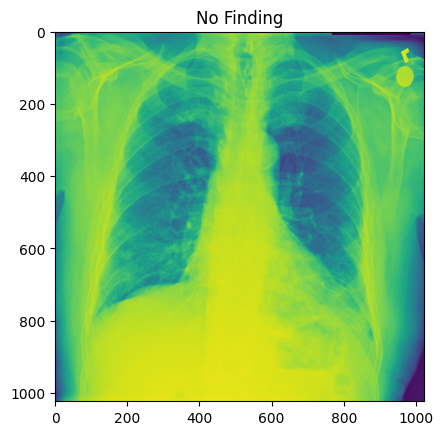

In [26]:
row = train_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in train_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed image provides a human-readable check of one training example. If the title contains disease names, those are the positive labels for that row; otherwise, the example is labeled `No Finding`.


## 5. Build and check the validation dataset

The validation CSV is loaded with the same dataset class and transforms. Matching preprocessing across training and validation makes validation metrics easier to interpret, while the split itself remains patient-safe from the earlier preprocessing phase.


In [27]:
val_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/val_data.csv",  
    transforms=data_transform
)

image,labels = val_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The validation output should match the training sample structure: an image tensor shaped `[3, 224, 224]` and a label tensor shaped `[14]`.


A representative validation image is displayed with its positive labels. This gives a quick visual sanity check that the validation split uses the same image-path and label-reading logic as the training split.


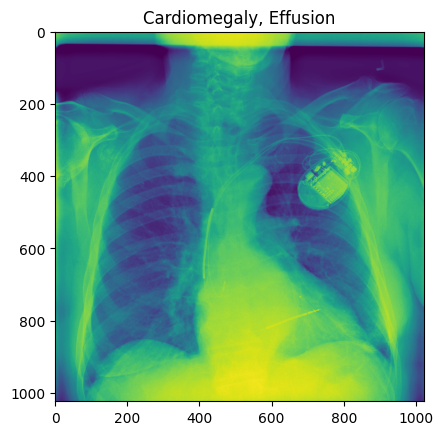

In [28]:
row = val_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in val_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed validation example provides a quick check that the validation image files and labels are aligned before the model uses this split for tuning.


## 6. Build and check the test dataset

The test CSV is loaded into the same dataset structure. Keeping test preprocessing identical to training and validation ensures the final evaluation measures model behavior rather than differences in input preparation.


In [29]:
test_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/test_data.csv",  
    transforms=data_transform
)
image,labels = test_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The test output should confirm the same tensor structure: image shape `[3, 224, 224]` and label shape `[14]`.


A representative test image is displayed with its positive labels. This final split-level visual check helps verify that the held-out evaluation data can be opened and interpreted consistently.


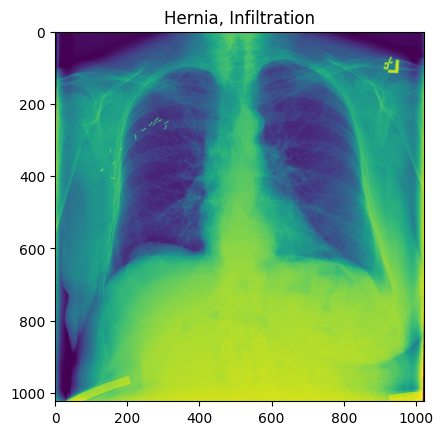

In [30]:
row = test_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in test_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed test example checks that the held-out split can be inspected in the same way as the training and validation splits.


## 7. Create the training DataLoader

The training dataset is wrapped in a `DataLoader` so the model can train on mini-batches instead of individual images. Shuffling is enabled for training to reduce dependence on CSV order, and `pin_memory=True` helps speed transfer to GPU when CUDA is available.


In [31]:
train_data = DataLoader(train_dataset,batch_size=64,shuffle=True,num_workers=4,pin_memory=True)

This cell does not print output. Successful execution creates `train_data`, the iterable batch loader used during the original one-time training run.


A batch-level check confirms that the training `DataLoader` combines individual samples correctly. This is important because the training loop expects image batches and label batches with matching first dimensions.


In [32]:
images, labels = next(iter(train_data))
print(images.shape, labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


The batch output should show images shaped `[64, 3, 224, 224]` and labels shaped `[64, 14]`. That means the loader is producing batches of 64 transformed X-rays with matching multi-label targets.


## 8. Create the validation DataLoader

The validation dataset is wrapped in a `DataLoader` with the same batch size. Validation data is not shuffled here so validation behavior remains stable and easier to reproduce.


In [33]:
val_data = DataLoader(val_dataset,batch_size=64,num_workers=4,pin_memory=True)

This cell does not print output. Successful execution creates `val_data`, which is used for both training-time validation and later checkpoint evaluation.


A validation batch is checked to confirm that the loader returns the same tensor contract as the training loader: one batch of transformed X-rays and one batch of multi-label targets.


In [34]:
images,labels = next(iter(val_data))
print(images.shape,labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


The validation batch output should match the training batch structure: images shaped `[64, 3, 224, 224]` and labels shaped `[64, 14]`.


## 9. Create the test DataLoader

The test dataset is wrapped in a final `DataLoader` for held-out evaluation. Using the same batch size and loading settings keeps evaluation code simple across validation and test splits.


In [35]:
test_data = DataLoader(test_dataset,batch_size=64,num_workers=4,pin_memory=True)

This cell does not print output. Successful execution creates `test_data`, preserving the official held-out split for final evaluation.


A test batch is checked as the final loading sanity check. Matching batch shapes across all splits means the same model forward pass and metric code can be reused.


In [36]:
images,labels = next(iter(test_data))
print(images.shape,labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64, 14])


The test batch output should also match the shared batch structure. Consistent DataLoader outputs across training, validation, and test splits make the model and metric code simpler.


## 10. Define the baseline CNN model

`MyModel` is a compact convolutional neural network for 14-label chest X-ray classification. It uses four convolutional blocks with channel sizes `32`, `64`, `128`, and `256`; each block applies convolution, batch normalization, ReLU activation, and max pooling. Adaptive average pooling reduces the spatial feature map before dropout and a final linear layer produce 14 logits.


In [37]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel,self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),                          
            nn.Dropout(0.3),
            nn.Linear(256, 14),                      
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.pool(x)
        x = self.head(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyModel().to(DEVICE)
print(DEVICE)

cuda


The printed device shows whether the notebook is using `cuda` or `cpu`. Moving the model to `DEVICE` ensures images, labels, and model weights can be placed on the same hardware.


## 11. Configure loss, optimizer, scheduler, and prediction helper

The model uses `BCEWithLogitsLoss`, which is appropriate for multi-label classification because each disease label is treated as an independent binary target. Adam optimization, weight decay, and a `StepLR` scheduler control parameter updates. The helper function converts logits to sigmoid probabilities, rounds them into binary predictions, and computes a simple label-wise accuracy.


In [38]:
criterion    = nn.BCEWithLogitsLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=2e-3,
                           betas=(0.9,0.999), eps=1e-08,
                           weight_decay=0.01, amsgrad=False)
scheduler    = StepLR(optimizer, step_size=2, gamma=0.95)

def accuracyFromLogits(output, target):
    scores = torch.sigmoid(output)
    pred   = torch.round(scores)
    correct = pred.eq(target.view_as(pred))
    accuracy = torch.mean(correct.type(torch.FloatTensor))
    return accuracy, scores, pred

This cell does not print output. Successful execution prepares the training objective, optimizer, scheduler, and logit-to-prediction helper used by the original training loop.


## 12. Train once and save the best checkpoint

This training loop was intended to run only once. It trains for up to 50 epochs, evaluates validation AUROC each epoch, and saves `baseline_model.pt` only when validation AUROC improves. After the best checkpoint has been created and uploaded as a Kaggle dataset input, later notebook runs should skip this expensive training cell and load the saved weights in the next section to save time and GPU usage.


In [ ]:
save_file_name = "baseline_model.pt"
max_epochs_stop = 5
best_auc_score = 0
best_epoch = 0
epochs_no_improve= 0
history = []
best_per_class = None
model.epochs = 0
overall_start = timer()

for epoch in range(50):
    model.train()
    train_loss, train_acc,n_train = 0.0,0.0,0
    start = timer()
    for idx, (images,labels) in enumerate(train_data):
            images = images.to(torch.float32).to(DEVICE)
            labels = labels.to(torch.float32).to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            assert outputs.shape == labels.shape
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            acc,_,_ = accuracyFromLogits(outputs,labels)
            train_acc += acc.item()
            n_train += 1

    train_loss /= n_train
    train_acc  /= n_train
    model.epochs += 1
    
    #Validate
    model.eval()
    val_loss, val_acc, n_val = 0.0,0.0,0
    all_scores,all_labels = [],[]
    with torch.no_grad():
        for images,labels in val_data:
            images = images.to(torch.float32).to(DEVICE)
            labels = labels.to(torch.float32).to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs,labels)
            val_loss += loss.item()
            acc,_,_ = accuracyFromLogits(outputs,labels)
            val_acc += acc.item()
            n_val += 1
            probs = torch.sigmoid(outputs)              # [B, 14]
            all_scores.append(probs.cpu().numpy())      # keep it 2D
            all_labels.append(labels.cpu().numpy())

    val_loss /= n_val
    val_acc /= n_val
    y_true  = np.concatenate(all_labels, axis=0)
    y_score = np.concatenate(all_scores, axis=0)
    y_pred  = (y_score >= 0.5).astype(int)

    auc = roc_auc_score(y_true,y_score,average="macro")
    # Per-class: arrays of length 14 (one value per disease)
    prec_pc, rec_pc, f1_pc, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0)

# Macro: single scalars for the epoch summary / training curve
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    history.append({
    "epoch":      model.epochs,
    "train_loss": train_loss,
    "val_loss":   val_loss,
    "val_auc":    auc,
    "macro_precision": macro_prec,
    "macro_recall":    macro_rec,
    "macro_f1":        macro_f1,
    })
    scheduler.step()
    auc_pc = roc_auc_score(y_true, y_score, average=None)   # ← add: length-14 per-class AUROC 

    per_class = {
    disease: {"auc": auc_pc[i], "precision": prec_pc[i], "recall": rec_pc[i],
              "f1": f1_pc[i], "support": int(support[i])}
    for i, disease in enumerate(train_dataset.target_cols)
}
    print(f'\nEpoch {epoch:03d} | Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {100*val_acc:.2f}% | AUC: {auc:.4f}')
    if auc > best_auc_score:
        torch.save(model.state_dict(),save_file_name)
        best_auc_score = auc
        epochs_no_improve = 0
        best_per_class = per_class
        best_epoch = epoch
        print(f"Model saved (val auc: {best_auc_score:.4f})")
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= max_epochs_stop:
        print(f"Early stopping at epoch {epoch}")
        break
history_df = pd.DataFrame(history)
print(f'\nDone. Best epoch: {best_epoch} | Best val AUC: {best_auc_score:.4f}')
print(f'Total time: {(timer()-overall_start)/60:.1f} minutes')

The output from the original training run would log epoch-by-epoch training loss, validation loss, validation accuracy, and validation AUROC, then report the best epoch and total runtime. In normal reruns, this cell should be left unexecuted once the checkpoint exists, because the next cell loads the saved best weights directly.


## 13. Load the best saved model weights for later runs

For every run after the original training run, the notebook rebuilds the same architecture and loads the best saved weights from `/kaggle/input/datasets/aarshdesai05/model-saved/baseline_model.pt`. This makes evaluation reproducible without spending GPU time retraining the same baseline model.


In [41]:
# 1) Rebuild the architecture and load the BEST weights
model = MyModel().to(DEVICE)                 # same class you trained
model.load_state_dict(torch.load("/kaggle/input/datasets/aarshdesai05/model-saved/baseline_model.pt", map_location=DEVICE, weights_only=True))
model.eval()
print("weights loaded ✓")

weights loaded ✓


The `weights loaded` message confirms that the notebook is using the saved best checkpoint instead of retraining. The model is set to evaluation mode so dropout and batch normalization behave correctly during metric calculation.


## 14. Define the evaluation helper and score validation data

The `evaluate` function runs the loaded model in inference mode, collects sigmoid probabilities for each disease label, and returns the true labels with the predicted scores. The validation predictions are thresholded at `0.5` to create binary predictions for precision, recall, and F1 calculations.


In [51]:
def evaluate(loader):
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(torch.float32).to(DEVICE)
            probs  = torch.sigmoid(model(images))     # [B,14] probabilities
            all_scores.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels, 0), np.concatenate(all_scores, 0)

y_true, y_score = evaluate(val_data)
y_pred = (y_score >= 0.5).astype(int)

This cell prepares validation predictions from the saved model. The resulting `y_true`, `y_score`, and `y_pred` arrays are used by the validation metric summary in the next cell.


## 15. Summarize validation metrics by disease label

The validation predictions are summarized with macro AUROC and per-class AUROC, precision, recall, F1, and support. Sorting by AUROC makes it easier to see which labels the baseline handles better on the validation split.


In [52]:
macro_auc = roc_auc_score(y_true, y_score, average="macro")
auc_pc = roc_auc_score(y_true, y_score, average=None)
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0)

per_class_val_df = pd.DataFrame(
    {"auc": auc_pc, "precision": prec, "recall": rec, "f1": f1, "support": support},
    index=val_dataset.target_cols
).sort_values("auc", ascending=False)

print(f"Val macro-AUROC: {macro_auc:.4f}")   
per_class_val_df 

Val macro-AUROC: 0.6940


,auc,precision,recall,f1,support
Edema,0.845663,0.0,0.0,0.0,144
Effusion,0.784205,0.0,0.0,0.0,1021
Consolidation,0.736156,0.0,0.0,0.0,310
Hernia,0.723943,0.0,0.0,0.0,26
Pneumothorax,0.708131,0.0,0.0,0.0,300
Atelectasis,0.694405,0.0,0.0,0.0,1044
Emphysema,0.689505,0.0,0.0,0.0,128
Pleural_Thickening,0.683334,0.0,0.0,0.0,311
Fibrosis,0.665701,0.0,0.0,0.0,167
Infiltration,0.658765,0.0,0.0,0.0,1592


**Key finding — a real baseline, and three lessons about how to read it.**

- **The model learns real signal:** validation macro-AUROC is **0.694**, well above the 0.5 random floor, so it genuinely ranks diseased images above healthy ones.
- **Accuracy would lie here:** every precision/recall/F1 in the table is **~0** at threshold 0.5 — yet a model predicting "no disease" for everything scores ~95% accuracy, because only ~4.5% of label slots are positive. That is exactly why this project reports **macro-AUROC**, not accuracy. The ~0 F1 is a *calibration / operating-point* issue (the probabilities are compressed below 0.5), **not** a ranking failure — the model ranks well (see the AUROC column), it just never crosses the default cutoff.
- **AUROC varies sharply by disease:** clear-signature findings (Edema 0.85, Effusion 0.78) rank far better than subtle ones (Nodule 0.61, Cardiomegaly 0.64). Those weak classes are the primary target for the transfer learning in Phase 4. (`Hernia`'s 0.72 is on just 26 positives — treat it as high-variance.)

The validation metrics table is saved as a CSV file in `/kaggle/working` so it can be downloaded or reused outside the notebook.


In [53]:
per_class_val_df.to_csv("/kaggle/working/per_class_val_baseline.csv")

This cell does not print output. Successful execution writes `per_class_val_baseline.csv` to the Kaggle working directory.


## 16. Evaluate the saved model on the test split

The loaded best checkpoint is evaluated on the held-out test `DataLoader`. This repeats the same metric calculation used for validation so final test behavior can be compared against the validation results.


In [54]:
y_true, y_score = evaluate(test_data)
y_pred = (y_score >= 0.5).astype(int)
macro_auc = roc_auc_score(y_true, y_score, average="macro")
auc_pc = roc_auc_score(y_true, y_score, average=None)
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0)

per_class_test_df = pd.DataFrame(
    {"auc": auc_pc, "precision": prec, "recall": rec, "f1": f1, "support": support},
    index=val_dataset.target_cols
).sort_values("auc", ascending=False)

print(f"Test macro-AUROC: {macro_auc:.4f}")   


Test macro-AUROC: 0.6043


**Key finding — a validation-to-test generalization gap.** Test macro-AUROC is **0.604**, versus **0.694** on validation — a **~0.09 gap**. Because AUROC is prevalence-invariant, the test set's higher disease prevalence does not explain it; it reflects a genuine **distribution shift in the official NIH split** (a well-documented property), plus a little selection bias from tuning on validation. The **test number (0.60) is the honest generalization estimate**, and shrinking this gap becomes one of the goals Phase 4's transfer learning is measured against (where it drops to ~0.03).

The test metrics table is saved as a CSV file in `/kaggle/working` so the final baseline results can be exported.


In [55]:
per_class_test_df.to_csv("/kaggle/working/per_class_test_baseline.csv")

This cell does not print output. Successful execution writes `per_class_test_baseline.csv` to the Kaggle working directory.


## Phase 3 Baseline Evaluation Summary

**Key result — an honest baseline: validation macro-AUROC 0.694, test 0.604 (a ~0.09 generalization gap).** The from-scratch CNN ranks diseased images well but shows ~0 F1 at threshold 0.5 (an operating-point artifact of class imbalance, not a modeling failure), and a real validation-to-test gap driven by the NIH split's distribution shift. These two numbers are the "before" that Phase 4's transfer learning is measured against.

- Reused the Phase 2 dataset-loading structure so the model uses the same patient-safe train, validation, and test splits.
- Loaded X-rays from the Phase 1 `full_path` column and converted every image to RGB tensors.
- Applied consistent resizing, tensor conversion, and normalization across all splits.
- Built training, validation, and test `DataLoader` objects with batch size `64`, `num_workers=4`, and pinned memory for faster GPU transfer.
- Defined a baseline CNN with four convolutional blocks, adaptive average pooling, dropout, and a 14-logit output layer.
- Configured `BCEWithLogitsLoss`, Adam with weight decay, and `StepLR` for the original training run.
- Ran the full training loop only once to create the best checkpoint, saving `baseline_model.pt` when validation AUROC improved.
- Used the saved checkpoint in later runs by loading it instead of retraining, keeping validation and test results reproducible while saving GPU time.
- Evaluated the saved baseline model on validation and test data with macro AUROC plus per-class AUROC, precision, recall, F1, and support.
- Exported validation and test per-class metric tables to CSV files in `/kaggle/working`.